# Подготовка анализа записей эпох с пилотного эксперимента с подачей ТМС импульса в разные фазы представляемого движения

Цель:
- Проверить структуру файлов с эпохами
- Посмотреть на данные
- Подготовить функции для анализа всех данных

Dataset: pilot/M1_SMA_differentPhases/clean_epochs <br>
Date: 2026-03-01

In [6]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = C:\Users\hodor\Documents\lab-MSU\Works\2025.10_TMS\TEP_analysis


In [1]:
# === imports ===
import pandas as pd 
import numpy as np 
from h5py import File 
import os 

In [2]:
# graphics
import matplotlib.pyplot as plt 
import seaborn as sns
from mne.viz import plot_topomap
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

In [3]:
# calculation and filters and etc
# from scipy.signal import butter, sosfiltfilt 

In [7]:
from src.utils.montage_processing import *

In [132]:
# === config ===
DATASET = "pilot/M1_SMA_differentPhases/clean_epochs"
data_folder = os.path.join(r"../data", DATASET)
records = os.listdir(data_folder)
record = records[0]
filename = os.path.join(data_folder, record)

In [133]:
record

'M1_session_19__set_1_coilФpa.h5'

In [10]:
Fs = 5000
ms_to_samples = lambda t: int(t / 1000 * Fs)

In [11]:
EEG_CHANNELS = np.arange(64)
CED_FILE = r"../resources/mks64_standard.ced"

ch_labels = get_channel_names(CED_FILE)
positions = get_topo_positions(CED_FILE)

labels_ROA = ["FC5", "FC3", "FC1", "C1", "CP1", "CP3", "CP5", "C5", "C3"] 
idxs_ROA = [find_ch_idx(ch, CED_FILE) for ch in labels_ROA]
idx_Fz = find_ch_idx("Fz", CED_FILE)

In [12]:
bad_channels = ['T7',  'TP9',   'P7',  'FT9',   'F7',   'O1',  'Fp1',  'Fp2',   'O2',
   'Oz',   'F8', 'FT10',   'P8',   'T8', 'TP10',  'FT7',  'TP7',  'AF7',
  'PO7',  'Fpz',  'PO8',  'AF8',  'FT8',  'TP8']#["FT9", "TP9", "FT10", "TP10"]
idxs_bad = [find_ch_idx(ch, CED_FILE) for ch in bad_channels]
idxs_good = np.array([ch for ch in np.arange(64) if not ch in idxs_bad])
idxs_good

array([ 3,  6,  7,  8,  9, 10, 13, 14, 16, 17, 18, 19, 22, 23, 24, 25, 28,
       35, 36, 37, 38, 39, 40, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53,
       55, 56, 57, 58, 59, 60])

In [13]:
REGION_COLORS = {
    "frontal": "#4C72B0",        # синий
    "central": "#DD8452",        # оранжевый (sensorimotor)
    "parietal": "#DDCC77",       # жёлтый
    "temporal": "#55A868",       # зелёный
    "occipital": "#C44E52",      # красный
    "prefrontal": "#8172B2",     # фиолетовый
}
EEG64_REGION_COLOR = {

    # --- Prefrontal ---
    "Fp1": "#8172B2",
    "Fp2": "#8172B2",
    "AF3": "#8172B2",
    "AF4": "#8172B2",
    "AF7": "#8172B2",
    "AF8": "#8172B2",
    'FT9': "#8172B2",
    'FT10': "#8172B2",
    'Fpz': "#8172B2",

    # --- Frontal ---
    "F1": "#4C72B0",
    "F2": "#4C72B0",
    "F3": "#4C72B0",
    "F4": "#4C72B0",
    "F5": "#4C72B0",
    "F6": "#4C72B0",
    "F7": "#4C72B0",
    "F8": "#4C72B0",
    "Fz": "#4C72B0",

    # --- Fronto-central / Premotor → central color ---
    "FC1": "#DD8452",
    "FC2": "#DD8452",
    "FC3": "#DD8452",
    "FC4": "#DD8452",
    "FC5": "#DD8452",
    "FC6": "#DD8452",
    "FCz": "#DD8452",

    # --- Central (Sensorimotor) ---
    "C1": "#DD8452",
    "C2": "#DD8452",
    "C3": "#DD8452",
    "C4": "#DD8452",
    "C5": "#DD8452",
    "C6": "#DD8452",
    "Cz": "#DD8452",

    # --- Centro-parietal ---
    "CP1": "#DDCC77",
    "CP2": "#DDCC77",
    "CP3": "#DDCC77",
    "CP4": "#DDCC77",
    "CP5": "#DDCC77",
    "CP6": "#DDCC77",
    "CPz": "#DDCC77",

    # --- Parietal ---
    "P1": "#DDCC77",
    "P2": "#DDCC77",
    "P3": "#DDCC77",
    "P4": "#DDCC77",
    "P5": "#DDCC77",
    "P6": "#DDCC77",
    "P7": "#DDCC77",
    "P8": "#DDCC77",
    "Pz": "#DDCC77",

    # --- Temporal ---
    "FT7": "#55A868",
    "FT8": "#55A868",
    "T7": "#55A868",
    "T8": "#55A868",
    "TP7": "#55A868",
    "TP8": "#55A868",
    "TP9": "#55A868",
    "TP10": "#55A868",

    # --- Parieto-occipital ---
    "PO3": "#C44E52",
    "PO4": "#C44E52",
    "PO7": "#C44E52",
    "PO8": "#C44E52",
    "POz": "#C44E52",

    # --- Occipital ---
    "O1": "#C44E52",
    "O2": "#C44E52",
    "Oz": "#C44E52",
}

In [14]:
df = pd.read_csv(CED_FILE, sep='\t')
df["colors"] = df["labels"].map(EEG64_REGION_COLOR)
colors = df["colors"].values

In [15]:
from matplotlib import colormaps as cm
from matplotlib.colors import ListedColormap
viridisBig = cm.get_cmap('jet')
newcmp = ListedColormap(viridisBig(np.linspace(0, 1, 15)))

In [134]:
# === data === 
with File(filename, "r") as h5f:
    print(h5f['data'].keys())
    epochs = h5f['data/Epruned'][:]
    time = h5f['data/tvec'][:][0]
    conds = h5f['data/conds'][:]

<KeysViewHDF5 ['Epruned', 'tvec', 'conds']>


In [135]:
epochs.shape, time.shape, conds.shape

((3501, 75, 64), (3501,), (75, 3))

In [136]:
pre_mask = conds[:, 0].astype(bool)
imag_mask = conds[:, 1].astype(bool)
post_mask = conds[:, 2].astype(bool)

In [137]:
TEP_pre = np.mean(epochs[:, pre_mask, :], axis=1)#[:, idxs_good]
TEP_im = np.mean(epochs[:, imag_mask, :], axis=1)#[:, idxs_good]
TEP_post = np.mean(epochs[:, post_mask, :], axis=1)#[:, idxs_good]
TEP_im.shape

(3501, 64)

Text(0.5, 0.98, 'M1_session_19__set_1_coilФpa.h5')

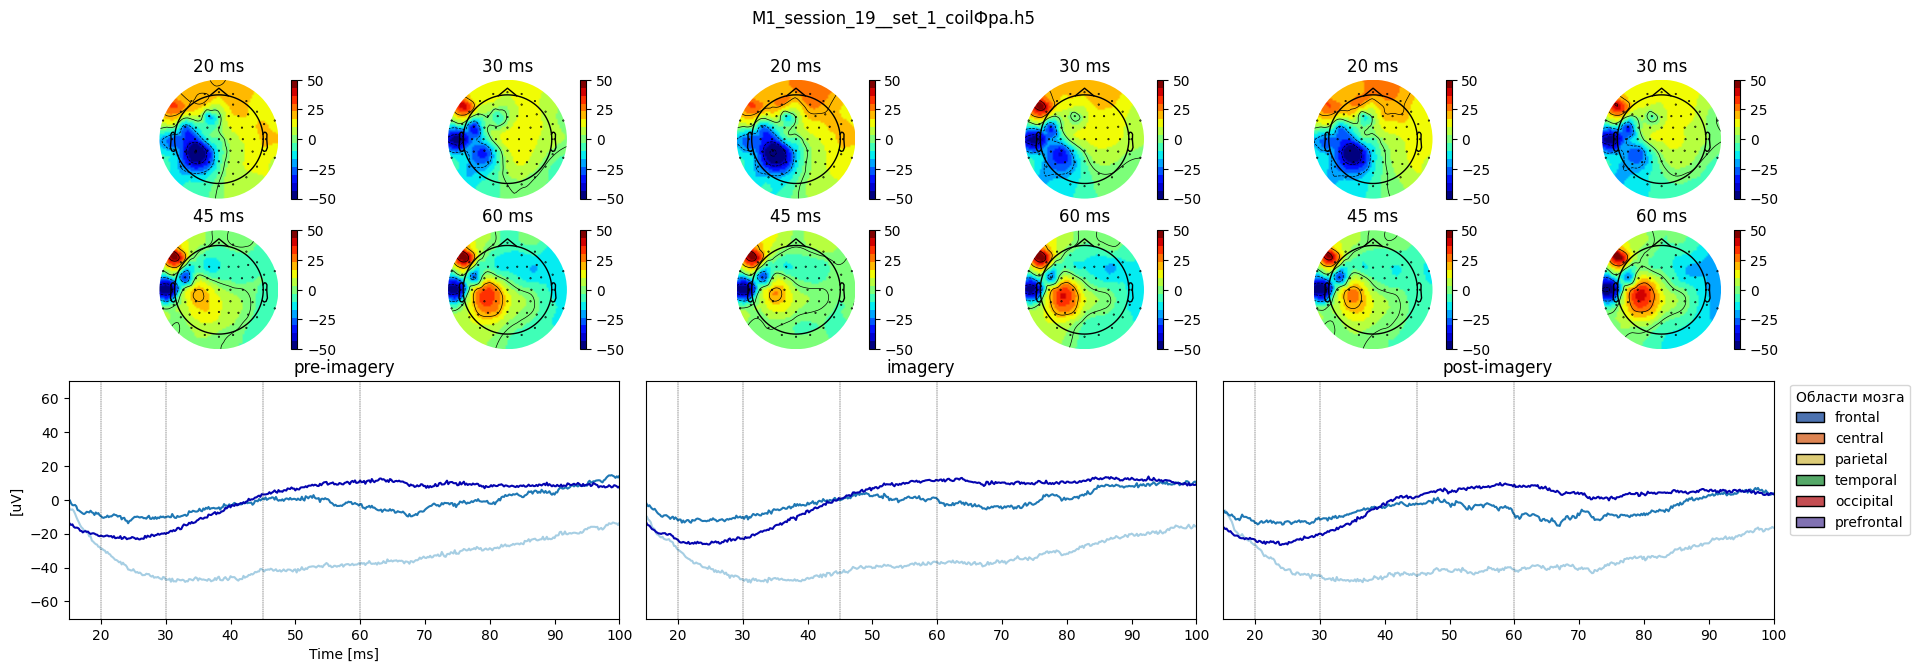

In [138]:
fig = plt.figure(figsize=(22, 7))
gs = gridspec.GridSpec(3, 6,  height_ratios = [1, 1, 2], wspace=0.1)

titles = ["pre-imagery", "imagery", "post-imagery"]

time_limits = [15, 100]
shift = 200
time_range = np.arange(ms_to_samples(time_limits[0]+shift), ms_to_samples(time_limits[1]+shift))
def find_max(X, range):
     return np.max(np.abs(X[range, :]))

amp = np.max([find_max(TEP_pre, time_range), find_max(TEP_im, time_range), find_max(TEP_post, time_range)])
h = 2
axis = [plt.subplot(gs[h, 0:2]), plt.subplot(gs[h, 2:4]), plt.subplot(gs[h, 4:6])]
def plot_butterfly(TEPs, ax, time, amp, time_range):
    for color, TEP in zip(colors, TEPs.T):
        ax.plot(time, TEP, color=color)
    ax.set_ylim(-amp, amp)
    ax.set_xlim(time_range)
    ax.set_title(titles[i])
   
for i, TEPs in enumerate([TEP_pre, TEP_im, TEP_post]):
    plot_butterfly(TEPs,  axis[i], time=time, amp=amp, time_range=time_limits)

axis[0].set_xlabel("Time [ms]")
axis[0].set_ylabel("[uV]")

axis[1].set_yticks([])
axis[2].set_yticks([])

time_moments = [20, 30, 45, 60]

def plot_timemoments(ax, time_moments):
    for time_moment in time_moments:
        ax.axvline(time_moment, color="black", linestyle="--", linewidth=.3)

for ax in axis:
      plot_timemoments(ax, time_moments)

legend_elements = [Patch(facecolor=color, edgecolor='k', label=area)
                   for area, color in REGION_COLORS.items()]
axis[2].legend(handles=legend_elements, title="Области мозга", loc=[1.03,.35])

for i, TEPs in enumerate([TEP_pre, TEP_im, TEP_post]):
    axis = [plt.subplot(gs[0, 0+2*i]), plt.subplot(gs[0, 1+2*i]), plt.subplot(gs[1, 0+2*i]), plt.subplot(gs[1, 1+2*i])]
    for j in np.arange(len(time_moments)):
            time_moment = time_moments[j]+shift
            range = 5
            start, end = time_moment - range, time_moment + range         # ms
            time_moment = np.arange(ms_to_samples(start), ms_to_samples(end)+1)
            TEP_t = np.mean(TEPs[time_moment, :], 0)
            im, cn = plot_topomap(TEP_t, positions,  image_interp='cubic', ch_type='eeg', #names = ch_labels,
                    size=5, show=False, contours=4, sphere=0.5, cmap=newcmp, extrapolate='head', axes=axis[j], vlim=[-50, 50])
            fig.colorbar(im)
            axis[j].set_title("{} ms".format(time_moments[j]))

fig.suptitle(record)

(15.0, 100.0)

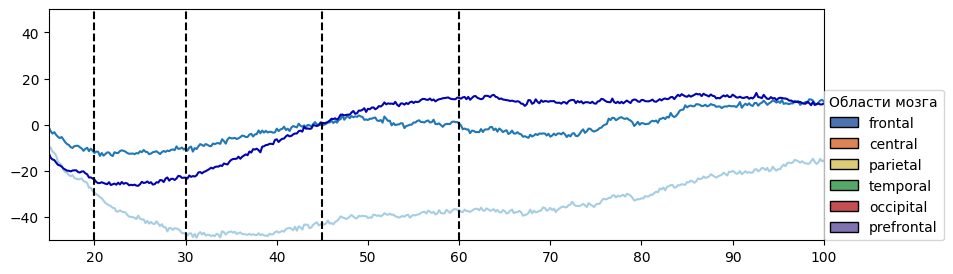

In [139]:
plt.figure(figsize=(10, 3))
for color, TEP in zip(colors, TEP_im.T):
    plt.plot(time, TEP, color=color)
# plt.legend(ch_labels[idxs_good]);
legend_elements = [Patch(facecolor=color, edgecolor='k', label=area)
                   for area, color in REGION_COLORS.items()]
plt.legend(handles=legend_elements, title="Области мозга", loc=[1,0])
time_moments = [20, 30, 45, 60]
for time_moment in time_moments:
    plt.axvline(time_moment, color="black", linestyle="--")
plt.ylim(-50, 50)
plt.xlim(15, 100)

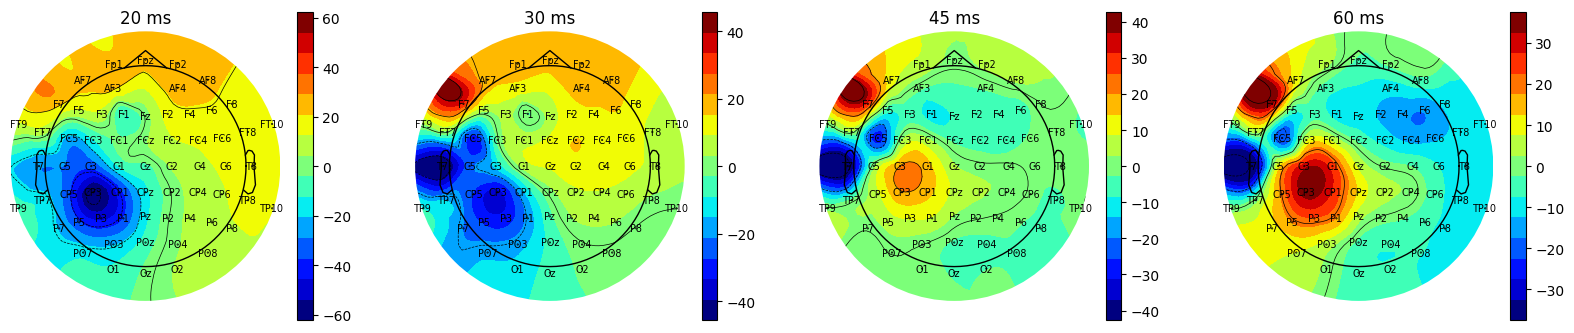

In [140]:
shift = 200
time_moments = [20, 30, 45, 60]
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
for i in np.arange(len(time_moments)):
        time_moment = time_moments[i]+shift
        range = 5
        start, end = time_moment - range, time_moment + range         # ms
        time_moment = np.arange(ms_to_samples(start), ms_to_samples(end)+1)
        TEP_t = np.mean(TEP_im[time_moment, :], 0)
        im, cn = plot_topomap(TEP_t, positions,  image_interp='cubic', ch_type='eeg', names = ch_labels,
                size=5, show=False, contours=4, sphere=0.5, cmap=newcmp, extrapolate='head', axes=ax[i])
        fig.colorbar(im)
        ax[i].set_title("{} ms".format(time_moments[i]))

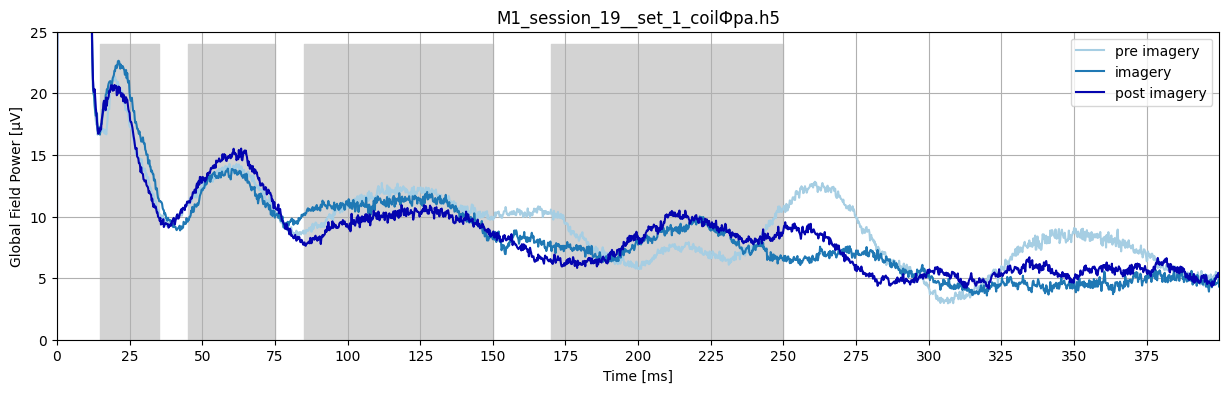

In [141]:

fig, ax = plt.subplots(1, 1, figsize=(15, 4))
colors = ["#A6CEE3", "#1F78B4", "#0404AF"]
# titles = 
for title, TEPs, color in zip(["pre imagery", "imagery",  "post imagery"], [TEP_pre, TEP_im, TEP_post], colors):
    gfp = np.std(TEPs, axis=1)
    ax.plot(time, gfp, label=title, color=color)

max_x = 400
max_y = 25

for interval in [[15, 35], [45, 75], [85, 150], [170, 250]]:
    ax.fill_betweenx(np.arange(max_y), interval[0], interval[1], color="lightgrey")

ax.set_ylim(0, max_y)
ax.set_xlim(0, max_x)
ax.set_xticks(np.arange(0, max_x, 25))
ax.set_ylabel("Global Field Power [µV]")
ax.set_xlabel("Time [ms]")
ax.set_title(record)
ax.grid()
ax.legend()

In [142]:
from scipy.signal import find_peaks, savgol_filter


def compute_gfp(teps):
    """Compute Global Field Power."""
    return np.std(teps, axis=1)


def find_gfp_peaks(
    TEPs,
    times,
    sfreq=5000,
    smooth_ms=10,
    min_distance_ms=20,
    prominence_factor=1.5,
    width_ms=5,
):
    """
    Robust GFP peak detection.
    
    Parameters
    ----------
    TEPs : [samples, channels]
    times: ms
    smooth_ms : smoothing window (ms)
    min_distance_ms : minimal distance between peaks
    prominence_factor : peak prominence relative to noise
    width_ms : minimal peak width
    """


    # --- GFP ---
    gfp = compute_gfp(TEPs)

    # --- smoothing (Savitzky-Golay preserves peaks) ---
    win = int(smooth_ms * sfreq / 1000)
    win = win + 1 if win % 2 == 0 else win  # must be odd
    gfp_smooth = savgol_filter(gfp, win, polyorder=3)

    # адаптивный prominence
    dynamic_range = gfp_smooth.max() - gfp_smooth.min()
    prominence = 0.05 * dynamic_range  # 5% от размаха
    height = np.mean(gfp_smooth)
    distance = int(0.015 * sfreq)  # 15 ms

    
    peaks, props = find_peaks(
        gfp_smooth,
        prominence=prominence,
        height=height,
        distance=distance
    )

    return times[peaks], gfp_smooth, peaks, props

    # return {
    #     "peaks_samples": peaks,
    #     "peaks_times_ms": times[peaks],
    #     "peaks_amplitude": gfp_smooth[peaks],
    #     "gfp": gfp,
    #     "gfp_smooth": gfp_smooth,
    #     "properties": properties,
    # }

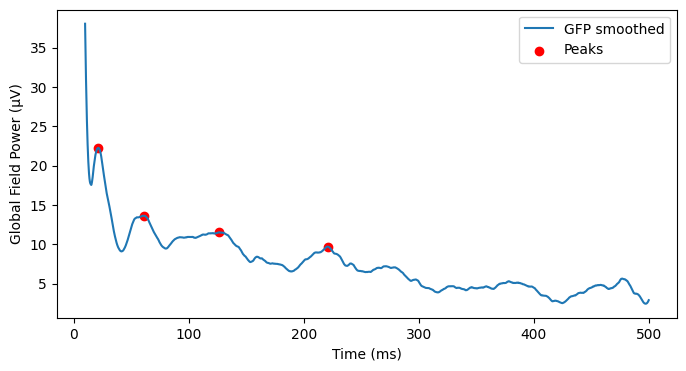

Peaks at (ms): [ 21.4  61.4 126.4 220.8]


In [144]:
start = int((10 + shift) / 1000 * Fs) 
t_peaks, gfp_s, peaks, props = find_gfp_peaks(TEP_im[start:], time[start:])

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(time[start:], gfp_s, label="GFP smoothed")
plt.scatter(t_peaks, gfp_s[peaks], color='red', label="Peaks")
plt.xlabel("Time (ms)")
plt.ylabel("Global Field Power (µV)")
plt.legend()
plt.show()

print("Peaks at (ms):", t_peaks)

Peaks at (ms): [ 21.4  61.4 126.4 220.8]


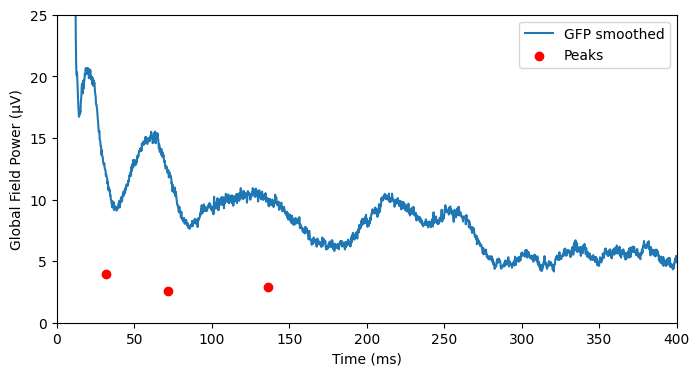

In [145]:
plt.figure(figsize=(8,4))
plt.plot(time, gfp, label="GFP smoothed")
plt.scatter(t_peaks+10, gfp[peaks], color='red', label="Peaks")
plt.xlabel("Time (ms)")
plt.ylabel("Global Field Power (µV)")
plt.legend()

plt.ylim(0, max_y)
plt.xlim(0, max_x)
print("Peaks at (ms):", t_peaks)
plt.show()

In [ ]:
t_peaks-shift, gfp_s[peaks]

(array([ 21.4,  60.6, 128.6, 216.2, 329.2, 371.4, 431.2]),
 array([10.853893 ,  9.655429 ,  9.854762 ,  8.623602 ,  7.543985 ,
         6.2936625,  5.780149 ], dtype=float32))

In [113]:
print("GFP range:", gfp.min(), gfp.max())
print("Noise estimate:", noise_level)

GFP range: 0.56993866 218.0312


NameError: name 'noise_level' is not defined

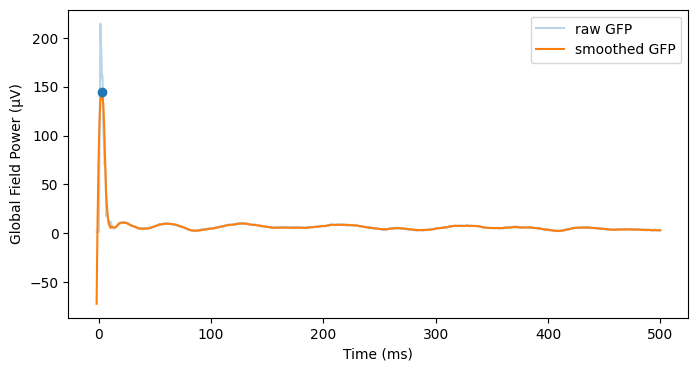

In [112]:
plt.figure(figsize=(8,4))
plt.plot(time[start:], result["gfp"], alpha=0.3, label="raw GFP")
plt.plot(time[start:], result["gfp_smooth"], label="smoothed GFP")

plt.scatter(
    result["peaks_times_ms"],
    result["peaks_amplitude"],
    zorder=3,
)
# plt.xlim(15, 100)
plt.xlabel("Time (ms)")
plt.ylabel("Global Field Power (µV)")
plt.legend()
plt.show()